# Day 6 - Advanced Analytics and Risk Metrics

This notebook computes tail-risk, rolling Sharpe, investor cohort behavior, SIP continuity, and portfolio concentration analytics for the Bluestock Mutual Fund platform.

In [1]:
from __future__ import annotations

import sqlite3
from pathlib import Path
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


def resolve_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / 'data' / 'db' / 'bluestock_mf.db').exists():
            return candidate
    raise FileNotFoundError(
        "Unable to locate 'data/db/bluestock_mf.db' from the current notebook working directory."
    )


BASE_DIR = resolve_project_root()
DB_PATH = BASE_DIR / 'data' / 'db' / 'bluestock_mf.db'
RAW_DIR = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
REPORTS_DIR = BASE_DIR / 'reports'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {BASE_DIR}')
print(f'Database path: {DB_PATH}')

Project root: /Users/sayonmanna/project 2
Database path: /Users/sayonmanna/project 2/data/db/bluestock_mf.db


In [2]:
def read_sqlite_table(table_name: str) -> pd.DataFrame:
    if not DB_PATH.exists():
        raise FileNotFoundError(f'SQLite database not found at {DB_PATH}')
    conn = sqlite3.connect(DB_PATH.as_posix())
    try:
        return pd.read_sql_query(f'SELECT * FROM {table_name}', conn)
    finally:
        conn.close()


def read_csv_asset(relative_path: Path) -> pd.DataFrame:
    if not relative_path.exists():
        raise FileNotFoundError(f'CSV file not found at {relative_path}')
    return pd.read_csv(relative_path)


def normalize_date_columns(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    out = df.copy()
    for column in columns:
        if column in out.columns:
            out[column] = pd.to_datetime(out[column], errors='coerce')
    return out


def gap_fill_nav(nav_df: pd.DataFrame) -> pd.DataFrame:
    nav_df = nav_df.copy()
    nav_df['nav_date'] = pd.to_datetime(nav_df['nav_date'], errors='coerce')
    nav_df = nav_df.dropna(subset=['amfi_code', 'nav_date', 'nav'])
    nav_df = nav_df[nav_df['nav'] > 0]
    nav_df = nav_df.sort_values(['amfi_code', 'nav_date'])

    filled_frames = []
    for amfi_code, group in nav_df.groupby('amfi_code', sort=True):
        idx = pd.date_range(group['nav_date'].min(), group['nav_date'].max(), freq='D')
        filled = group.set_index('nav_date')[['nav']].reindex(idx).ffill()
        filled['amfi_code'] = amfi_code
        filled = filled.reset_index().rename(columns={'index': 'nav_date'})
        filled_frames.append(filled[['amfi_code', 'nav_date', 'nav']])

    return pd.concat(filled_frames, ignore_index=True)


def build_return_frame(nav_df: pd.DataFrame, fund_dim: pd.DataFrame) -> pd.DataFrame:
    filled = gap_fill_nav(nav_df)
    filled = filled.sort_values(['amfi_code', 'nav_date'])
    filled['daily_return'] = filled.groupby('amfi_code')['nav'].pct_change()
    return filled.merge(fund_dim[['amfi_code', 'scheme_name', 'fund_house', 'category', 'sub_category']], on='amfi_code', how='left')


def select_diversified_funds(perf_df: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    candidates = perf_df.copy()
    candidates['aum_crore'] = pd.to_numeric(candidates.get('aum_crore'), errors='coerce')
    candidates['sharpe_ratio'] = pd.to_numeric(candidates.get('sharpe_ratio'), errors='coerce')
    candidates = candidates.dropna(subset=['aum_crore', 'sharpe_ratio']).sort_values(
        ['aum_crore', 'sharpe_ratio'], ascending=[False, False]
    )

    chosen_rows = []
    seen_segments = set()
    for _, row in candidates.iterrows():
        segment_key = row.get('sub_category') or row.get('category') or row.get('fund_house')
        if segment_key not in seen_segments:
            chosen_rows.append(row)
            seen_segments.add(segment_key)
        if len(chosen_rows) == n:
            break

    if len(chosen_rows) < n:
        for _, row in candidates.iterrows():
            if row['amfi_code'] not in [chosen['amfi_code'] for chosen in chosen_rows]:
                chosen_rows.append(row)
            if len(chosen_rows) == n:
                break

    return pd.DataFrame(chosen_rows).reset_index(drop=True)


def compute_var_cvar_report(returns_df: pd.DataFrame, fund_dim: pd.DataFrame) -> pd.DataFrame:
    records = []
    for amfi_code, group in returns_df.groupby('amfi_code', sort=True):
        valid_returns = group['daily_return'].dropna()
        if valid_returns.empty:
            continue
        var_95 = valid_returns.quantile(0.05)
        cvar_95 = valid_returns[valid_returns <= var_95].mean()
        records.append({
            'amfi_code': amfi_code,
            'scheme_name': group['scheme_name'].dropna().iloc[0] if group['scheme_name'].notna().any() else None,
            'fund_house': group['fund_house'].dropna().iloc[0] if group['fund_house'].notna().any() else None,
            'category': group['category'].dropna().iloc[0] if group['category'].notna().any() else None,
            'observations': int(valid_returns.shape[0]),
            'var_95_daily': float(var_95),
            'cvar_95_daily': float(cvar_95),
            'mean_daily_return': float(valid_returns.mean()),
            'volatility_daily': float(valid_returns.std()),
        })

    report = pd.DataFrame(records).merge(
        fund_dim[['amfi_code', 'risk_category', 'expense_ratio_pct']], on='amfi_code', how='left'
    )
    report = report.sort_values('var_95_daily').reset_index(drop=True)
    return report


def build_rolling_sharpe_frame(returns_df: pd.DataFrame, selected_funds: pd.DataFrame) -> pd.DataFrame:
    selected_codes = selected_funds['amfi_code'].tolist()
    selected_names = selected_funds.set_index('amfi_code')['scheme_name'].to_dict()
    filtered = returns_df[returns_df['amfi_code'].isin(selected_codes)].copy()

    records = []
    for amfi_code, group in filtered.groupby('amfi_code', sort=True):
        group = group.sort_values('nav_date').copy()
        rolling_mean = group['daily_return'].rolling(90).mean()
        rolling_std = group['daily_return'].rolling(90).std()
        rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
        frame = pd.DataFrame({
            'nav_date': group['nav_date'],
            'amfi_code': amfi_code,
            'scheme_name': selected_names.get(amfi_code),
            'rolling_sharpe_90d': rolling_sharpe,
        })
        records.append(frame)
    return pd.concat(records, ignore_index=True)


def build_cohort_summary(transactions_df: pd.DataFrame, fund_dim: pd.DataFrame) -> pd.DataFrame:
    tx = transactions_df.copy()
    tx['transaction_date'] = pd.to_datetime(tx['transaction_date'], errors='coerce')
    tx = tx.dropna(subset=['investor_id', 'amfi_code', 'transaction_date', 'amount_inr'])
    tx = tx[tx['amount_inr'] > 0]
    tx = tx.merge(fund_dim[['amfi_code', 'scheme_name', 'fund_house']], on='amfi_code', how='left')
    tx['cohort_year'] = tx.groupby('investor_id')['transaction_date'].transform('min').dt.year

    rows = []
    for cohort_year, cohort_group in tx.groupby('cohort_year', sort=True):
        sip_group = cohort_group[cohort_group['transaction_type'].astype(str).str.upper() == 'SIP']
        avg_sip_ticket = float(sip_group['amount_inr'].mean()) if not sip_group.empty else np.nan
        total_contribution = float(cohort_group['amount_inr'].sum())
        top_fund_name = cohort_group['scheme_name'].value_counts().idxmax() if cohort_group['scheme_name'].notna().any() else None
        top_fund_share = float(cohort_group['scheme_name'].value_counts(normalize=True).iloc[0]) if cohort_group['scheme_name'].notna().any() else np.nan
        rows.append({
            'cohort_year': int(cohort_year),
            'investor_count': int(cohort_group['investor_id'].nunique()),
            'avg_sip_ticket_inr': avg_sip_ticket,
            'total_cumulative_capital_inr': total_contribution,
            'top_fund_asset_preference': top_fund_name,
            'top_fund_trade_share': top_fund_share,
        })

    return pd.DataFrame(rows).sort_values('cohort_year').reset_index(drop=True)


def build_sip_continuity_report(transactions_df: pd.DataFrame) -> pd.DataFrame:
    sip = transactions_df.copy()
    sip['transaction_date'] = pd.to_datetime(sip['transaction_date'], errors='coerce')
    sip = sip.dropna(subset=['investor_id', 'transaction_date', 'amount_inr'])
    sip = sip[sip['transaction_type'].astype(str).str.upper() == 'SIP']
    sip = sip.sort_values(['investor_id', 'transaction_date'])

    rows = []
    for investor_id, group in sip.groupby('investor_id', sort=True):
        unique_dates = group['transaction_date'].drop_duplicates().sort_values()
        if unique_dates.nunique() < 6:
            continue
        avg_gap_days = unique_dates.diff().dt.days.dropna().abs().mean()
        rows.append({
            'investor_id': investor_id,
            'sip_record_count': int(unique_dates.shape[0]),
            'first_sip_date': unique_dates.min(),
            'last_sip_date': unique_dates.max(),
            'avg_gap_days': float(avg_gap_days) if pd.notna(avg_gap_days) else np.nan,
            'risk_flag': 'at-risk' if pd.notna(avg_gap_days) and avg_gap_days > 35 else 'retained',
        })

    return pd.DataFrame(rows).sort_values(['risk_flag', 'avg_gap_days'], ascending=[False, False]).reset_index(drop=True)


def build_hhi_report(holdings_df: pd.DataFrame, fund_dim: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    equity_funds = fund_dim[fund_dim['category'].astype(str).str.lower() == 'equity'][['amfi_code', 'scheme_name', 'fund_house', 'category']]
    merged = holdings_df.merge(equity_funds, on='amfi_code', how='inner')
    merged['weight_pct'] = pd.to_numeric(merged['weight_pct'], errors='coerce')
    merged = merged.dropna(subset=['weight_pct', 'sector'])

    sector_weights = merged.groupby(['amfi_code', 'scheme_name', 'fund_house', 'sector'], as_index=False)['weight_pct'].sum()
    sector_weights['sector_weight_share'] = sector_weights['weight_pct'] / sector_weights.groupby('amfi_code')['weight_pct'].transform('sum')

    hhi = sector_weights.groupby(['amfi_code', 'scheme_name', 'fund_house'], as_index=False).agg(
        sector_count=('sector', 'nunique'),
        total_sector_weight_pct=('weight_pct', 'sum'),
    )
    hhi_values = sector_weights.groupby(['amfi_code', 'scheme_name', 'fund_house'])['sector_weight_share'].apply(lambda s: float((s ** 2).sum())).reset_index(name='hhi')
    hhi = hhi.merge(hhi_values, on=['amfi_code', 'scheme_name', 'fund_house'], how='left')
    hhi['concentration_profile'] = np.where(hhi['hhi'] >= 0.18, 'High HHI', 'Low Diversified HHI')

    matrix = sector_weights.pivot_table(
        index='scheme_name',
        columns='sector',
        values='sector_weight_share',
        aggfunc='sum',
        fill_value=0.0,
    )
    matrix = matrix.loc[hhi.sort_values('hhi', ascending=False)['scheme_name'].head(12)]
    return hhi.sort_values('hhi', ascending=False).reset_index(drop=True), matrix

In [3]:
# Load the core tables and source assets.
dim_fund = read_sqlite_table('dim_fund')
fact_nav = read_sqlite_table('fact_nav')
fact_transactions = read_sqlite_table('fact_transactions')
performance = read_csv_asset(PROCESSED_DIR / 'clean_07_scheme_performance.csv')
fund_scorecard = read_csv_asset(PROCESSED_DIR / 'fund_scorecard.csv')
holdings = read_csv_asset(RAW_DIR / '09_portfolio_holdings.csv')
benchmark_indices = read_csv_asset(RAW_DIR / '10_benchmark_indices.csv')
performance_enriched = performance.merge(dim_fund[['amfi_code', 'sub_category']], on='amfi_code', how='left')

fact_nav = normalize_date_columns(fact_nav, ['nav_date'])
fact_transactions = normalize_date_columns(fact_transactions, ['transaction_date'])
performance = normalize_date_columns(performance, [])
fund_scorecard = normalize_date_columns(fund_scorecard, ['peak_date', 'trough_date'])
holdings = normalize_date_columns(holdings, ['portfolio_date'])
benchmark_indices = normalize_date_columns(benchmark_indices, ['date'])

print('Loaded core tables:')
print(f"  dim_fund: {dim_fund.shape}")
print(f"  fact_nav: {fact_nav.shape}")
print(f"  fact_transactions: {fact_transactions.shape}")
print(f"  performance: {performance.shape}")
print(f"  fund_scorecard: {fund_scorecard.shape}")
print(f"  holdings: {holdings.shape}")
print(f"  benchmark_indices: {benchmark_indices.shape}")

Loaded core tables:
  dim_fund: (40, 7)
  fact_nav: (64320, 4)
  fact_transactions: (32778, 8)
  performance: (40, 20)
  fund_scorecard: (40, 30)
  holdings: (322, 8)
  benchmark_indices: (8050, 3)


## 1. Tail-Risk Analytics: VaR and CVaR

In [4]:
returns_frame = build_return_frame(fact_nav, dim_fund)
var_cvar_report = compute_var_cvar_report(returns_frame, dim_fund)
var_cvar_output_path = PROCESSED_DIR / 'var_cvar_report.csv'
var_cvar_report.to_csv(var_cvar_output_path, index=False)

display(var_cvar_report.head(10))
print(f'Saved VaR/CVaR report to {var_cvar_output_path}')

,amfi_code,scheme_name,fund_house,category,observations,var_95_daily,cvar_95_daily,mean_daily_return,volatility_daily,risk_category,expense_ratio_pct
0,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,1607,-0.023915,-0.030289,0.000303,0.013741,Very High,1.53
1,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,1607,-0.023284,-0.029690,0.000130,0.013351,Very High,1.38
2,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,1607,-0.023155,-0.030163,0.000144,0.013289,Very High,0.72
3,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,1607,-0.022810,-0.029940,0.000506,0.013447,Very High,1.53
4,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,1607,-0.021520,-0.028573,0.000854,0.013241,Very High,1.52
5,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,1607,-0.021502,-0.028444,0.000859,0.013401,Very High,1.43
6,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,1607,-0.016997,-0.022375,0.000734,0.010347,High,1.38
7,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Equity,1607,-0.016950,-0.021251,0.000223,0.009532,High,1.56
8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,1607,-0.016902,-0.021850,0.000772,0.010097,High,1.38
9,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,1607,-0.016857,-0.021771,0.000079,0.009659,High,1.51


Saved VaR/CVaR report to /Users/sayonmanna/project 2/data/processed/var_cvar_report.csv


## 2. Rolling 90-Day Sharpe Trajectories

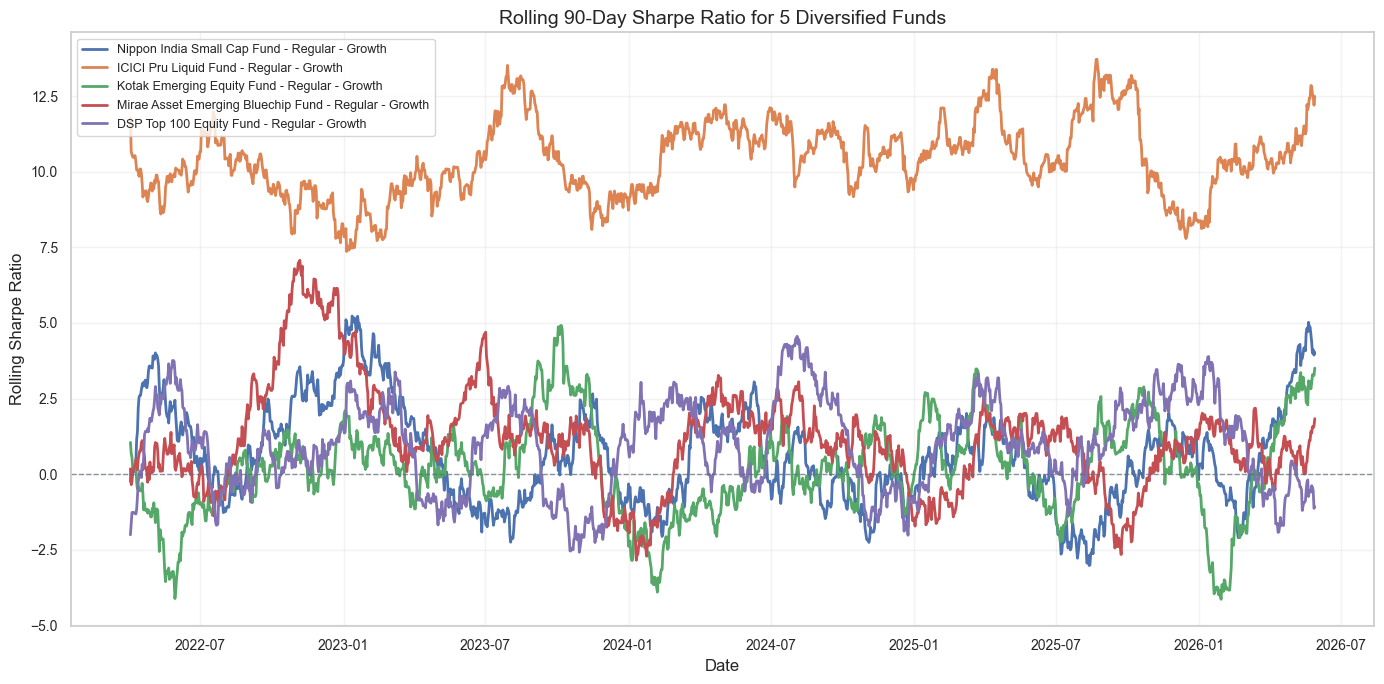

Saved rolling Sharpe chart to /Users/sayonmanna/project 2/reports/rolling_sharpe_chart.png


,amfi_code,scheme_name,fund_house,sub_category,aum_crore,sharpe_ratio
0,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,49046,0.91
1,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,47469,0.96
2,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,43630,0.81
3,149322,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,Large Cap,41828,0.92
4,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,39116,7.68


In [5]:
selected_funds = select_diversified_funds(performance_enriched, n=5)
rolling_sharpe_df = build_rolling_sharpe_frame(returns_frame, selected_funds)

fig, ax = plt.subplots(figsize=(14, 7))
for scheme_name, group in rolling_sharpe_df.groupby('scheme_name', sort=False):
    ax.plot(group['nav_date'], group['rolling_sharpe_90d'], linewidth=2.0, label=scheme_name)

ax.axhline(0, color='#5B6B7A', linewidth=1.0, linestyle='--', alpha=0.7)
ax.set_title('Rolling 90-Day Sharpe Ratio for 5 Diversified Funds')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Sharpe Ratio')
ax.legend(loc='upper left', frameon=True, fontsize=9)
ax.grid(True, alpha=0.25)
fig.tight_layout()

rolling_sharpe_path = REPORTS_DIR / 'rolling_sharpe_chart.png'
fig.savefig(rolling_sharpe_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved rolling Sharpe chart to {rolling_sharpe_path}')
display(selected_funds[['amfi_code', 'scheme_name', 'fund_house', 'sub_category', 'aum_crore', 'sharpe_ratio']])

## 3. Investor Cohort Engine

In [6]:
cohort_summary = build_cohort_summary(fact_transactions, dim_fund)
cohort_output_path = PROCESSED_DIR / 'cohort_analysis.csv'
cohort_summary.to_csv(cohort_output_path, index=False)

display(cohort_summary)
print(f'Saved cohort summary to {cohort_output_path}')

,cohort_year,investor_count,avg_sip_ticket_inr,total_cumulative_capital_inr,top_fund_asset_preference,top_fund_trade_share
0,2024,4803,10996.885825,3.491125e+09,Mirae Asset Emerging Bluechip Fund - Regular -...,0.026893
1,2025,197,13505.209581,3.045524e+07,ICICI Pru Liquid Fund - Regular - Growth,0.043011


Saved cohort summary to /Users/sayonmanna/project 2/data/processed/cohort_analysis.csv


## 4. SIP Continuity Analysis

In [7]:
sip_continuity_report = build_sip_continuity_report(fact_transactions)
sip_continuity_output_path = PROCESSED_DIR / 'sip_continuity_report.csv'
sip_continuity_report.to_csv(sip_continuity_output_path, index=False)

continuity_stats = {
    'qualified_investors': int(sip_continuity_report.shape[0]),
    'at_risk_investors': int((sip_continuity_report['risk_flag'] == 'at-risk').sum()) if not sip_continuity_report.empty else 0,
    'retention_rate_pct': float((sip_continuity_report['risk_flag'] != 'at-risk').mean() * 100) if not sip_continuity_report.empty else np.nan,
}

display(sip_continuity_report.head(20))
print('Continuity summary:', continuity_stats)
print(f'Saved SIP continuity report to {sip_continuity_output_path}')

,investor_id,sip_record_count,first_sip_date,last_sip_date,avg_gap_days,risk_flag
0,INV000566,7,2024-08-24,2025-03-22,35.000000,retained
1,INV003772,9,2024-03-19,2024-12-20,34.500000,retained
2,INV000707,9,2024-08-07,2025-05-09,34.375000,retained
3,INV003382,6,2024-07-13,2024-12-31,34.200000,retained
4,INV004246,7,2024-02-18,2024-09-10,34.166667,retained
5,INV004927,7,2024-02-25,2024-09-17,34.166667,retained
6,INV004542,7,2024-02-14,2024-09-05,34.000000,retained
7,INV003650,11,2024-02-24,2025-01-28,33.900000,retained
8,INV002509,10,2024-02-07,2024-12-06,33.666667,retained
9,INV002092,7,2024-05-20,2024-12-07,33.500000,retained


Continuity summary: {'qualified_investors': 1348, 'at_risk_investors': 1321, 'retention_rate_pct': 2.0029673590504453}
Saved SIP continuity report to /Users/sayonmanna/project 2/data/processed/sip_continuity_report.csv


## 5. Asset Portfolio Sector Concentration (HHI)

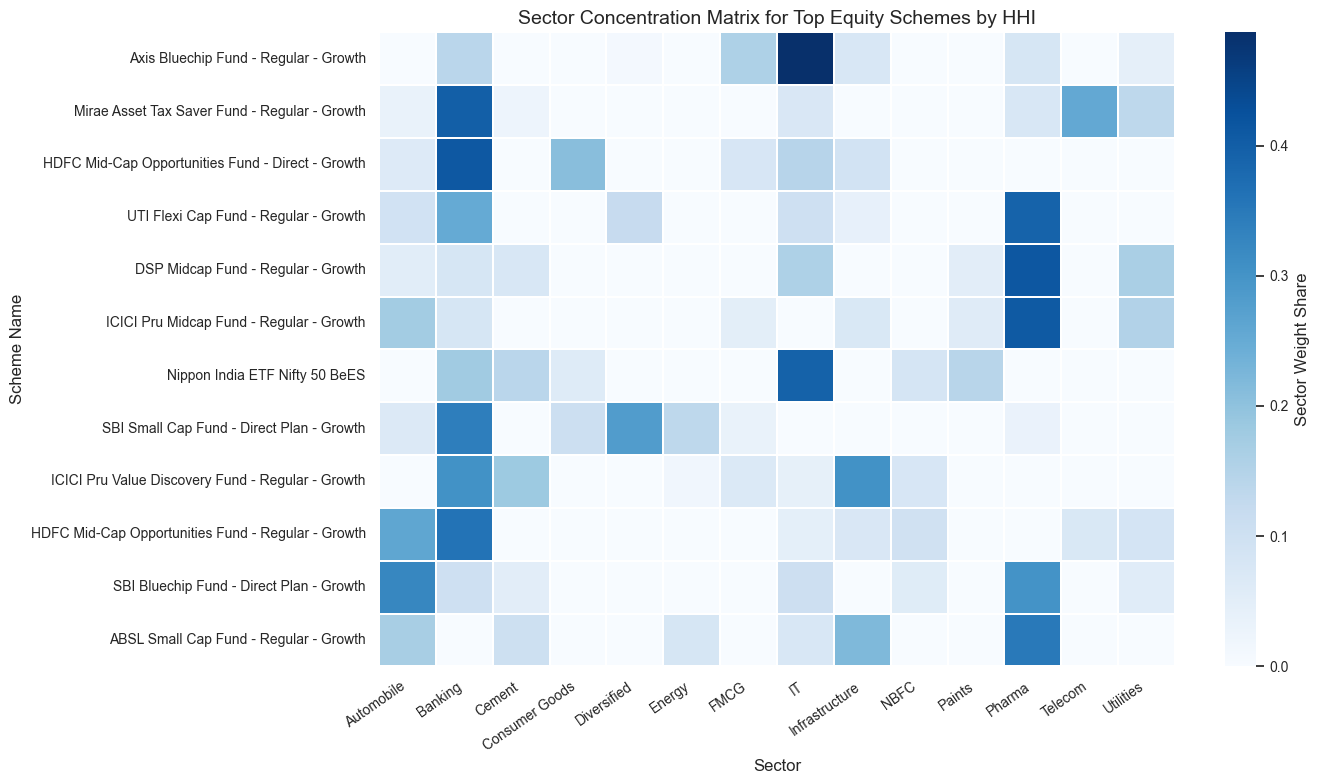

,amfi_code,scheme_name,fund_house,sector_count,total_sector_weight_pct,hhi,concentration_profile
0,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,7,99.99,0.296828,High HHI
1,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,7,99.98,0.255094,High HHI
2,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,6,100.00,0.253155,High HHI
3,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,6,100.01,0.251332,High HHI
4,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,7,100.00,0.241077,High HHI
5,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,7,100.02,0.238600,High HHI
6,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,6,99.99,0.237544,High HHI
7,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,7,100.00,0.232361,High HHI
8,120506,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,7,100.02,0.231372,High HHI
9,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,7,100.00,0.227647,High HHI


Saved HHI report to /Users/sayonmanna/project 2/data/processed/hhi_report.csv
Saved HHI concentration matrix to /Users/sayonmanna/project 2/reports/hhi_distribution_matrix.png


In [8]:
hhi_report, hhi_matrix = build_hhi_report(holdings, dim_fund)
hhi_output_path = PROCESSED_DIR / 'hhi_report.csv'
hhi_report.to_csv(hhi_output_path, index=False)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    hhi_matrix,
    cmap='Blues',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Sector Weight Share'},
    ax=ax,
)
ax.set_title('Sector Concentration Matrix for Top Equity Schemes by HHI')
ax.set_xlabel('Sector')
ax.set_ylabel('Scheme Name')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
fig.tight_layout()

hhi_matrix_path = REPORTS_DIR / 'hhi_distribution_matrix.png'
fig.savefig(hhi_matrix_path, dpi=300, bbox_inches='tight')
plt.show()

display(hhi_report.head(15))
print(f'Saved HHI report to {hhi_output_path}')
print(f'Saved HHI concentration matrix to {hhi_matrix_path}')

## Executive Summary

1. `../data/processed/var_cvar_report.csv` isolates the deepest daily tail-loss exposure across the 40 schemes, which is the clearest early-warning file for downside risk screening.
2. `../reports/rolling_sharpe_chart.png` shows whether the five diversified funds sustain risk-adjusted consistency over a full 90-day window or whether Sharpe compression is emerging.
3. `../data/processed/cohort_analysis.csv` highlights which investor cohorts contribute the highest capital and whether newer cohorts are already concentrating into a small number of preferred schemes.
4. `../data/processed/sip_continuity_report.csv` identifies investors whose SIP cadence has drifted beyond the retention threshold, with `at-risk` flags marking the weakest payment regularity.
5. `../data/processed/hhi_report.csv` and `../reports/hhi_distribution_matrix.png` reveal which equity schemes are structurally concentrated by sector and therefore most vulnerable to single-sector shocks.